# Crypto Cross-Sectional Momentum — the quant teardown 🪙

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survives the 2022 bear?: Busted](https://img.shields.io/badge/Survives_the_2022_bear%3F-Busted-8b949e?style=flat-square)

**Claim (Liu-Tsyvinski-Wu, JF 2022; Liu-Tsyvinski, RFS 2021).** Sort coins on past 1–4-week returns; winners minus losers earns a significant premium — momentum is the one robust return factor in crypto.

**Design.** 44-coin weekly panel (Binance spot 1w klines, Monday-open UTC weeks, spliced with yfinance `-USD` pre-listing backfills), 2017-01 → 2026-06, **11 delisted/dead pairs included** (LUNA truncated at its halt so the −100% week stays in and Terra 2.0 stays out). Rank at week-*t* close on the past *k*-week return; winners = top quintile, losers = bottom (`max(2, n//5)` names, equal-weight); earn the *t+1* close-to-close return — **exactly one execution lag**. Eligibility requires a valid formation return, a close at *t*, and a tradable *t+1* return (a halted coin's final print is not buyable; its crash weeks are). Inference: Newey-West *t* (Bartlett, 4 lags). Costs: one-way bps × measured traded NAV, short leg pays 10%/yr borrow. Returns are price-only in USD (spot coins pay no distributions); all legs gross unless labeled net.

> ⚠️ **Survivorship, named.** The delisted pairs soften the bias; the 33 live names are still-top-cap-in-2026 survivors and pre-2019 casualties without a Binance USDT pair are absent. This flatters *levels* more than the long-short *spread*, but it is a real tilt.

As-of **2026-06-28** (last complete UTC week) · fingerprint `df8a5231ba1d` · single source of truth: [docs/results.md](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_xs_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    RES = st.run_xs_momentum(PANEL, k=1)          # headline: 1-week formation
else:
    PANEL = RES = None
print("real panel cached:", HAVE_REAL,
      "| shape:", (None if PANEL is None else PANEL.shape),
      "| holding weeks:", (0 if RES is None else len(RES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2017-01-02', 'end_open': '2026-06-22', 'asof': '2026-06-28', 'years': 9.5, 'weeks': 495, 'coins': 44, 'n_delisted': 11, 'avg_n': 34.9, 'live_from': '2017-11-20', 'fingerprint': 'df8a5231ba1d', 'headline': [(1, 449, 164.1, 133.8, 3.56, 1.12, 55.0, 113.2, 3.3), (2, 448, 135.4, 101.8, 1.88, 0.66, 53.8, 114.0, 2.22), (3, 447, 197.8, 177.8, 2.95, 0.99, 55.5, 136.0, 2.63), (4, 446, 121.6, 87.9, 2.61, 0.83, 54.3, 76.8, 2.51)], 'mkt_bps': 148.0, 'mkt_t': 1.9, 'win_bps': 261.2, 'win_t': 2.6, 'subs': [('2017-2019', 111, 194.6, 173.4, 1.62, 55.9), ('2020-2021', 104, 371.6, 571.0, 3.8, 63.5), ('2022', 52, 10.5, 5.6, 0.13, 48.1), ('2023-2026', 182, 70.8, 44.5, 1.3, 51.6)], 'bull': (243, 255.8, 3.51, 1.47), 'bear': (206, 56.0, 1.13, 0.55), 'welch_diff': 2.09, 'to_win': 1.48, 'to_lose': 1.6, 'borrow_ann': 10.0, 'costs': [(10, 114.1, 80.7, 2.47, 98.4, 2.86), (25, 67.8, 42.3, 1.46, 76.1, 2.21), (50, -9.3, -4.7, -0.2, 39.0, 1.13)], 'placebo': {'seeds': 20, 'mean_bps': 7.2, 'std_bps': 36.4, 'mean_t': 0.2}, 'syn': [(0.0, -39.2, -1.09), (0.1, 396.7, 11.14)]}


real panel cached: True | shape: (495, 44) | holding weeks: 449


## 1 · Headline — the *k*-week sorts

The claim as stated is the **1-week** sort; 2–4-week formations are the robustness fan. Everything below recomputes live from the cached panel and must match `R` (= docs/results.md) exactly.

 k  weeks  WML bps/wk     ann%  HAC t    SR  hit%     WIN-MKT (t)
 1    449      +164.1   +133.8  +3.56  1.12  55.0    +113.2 (+3.30)


 2    448      +135.4   +101.8  +1.88  0.66  53.8    +114.0 (+2.22)


 3    447      +197.8   +177.8  +2.95  0.99  55.5    +136.0 (+2.63)


 4    446      +121.6    +87.9  +2.61  0.83  54.3     +76.8 (+2.51)


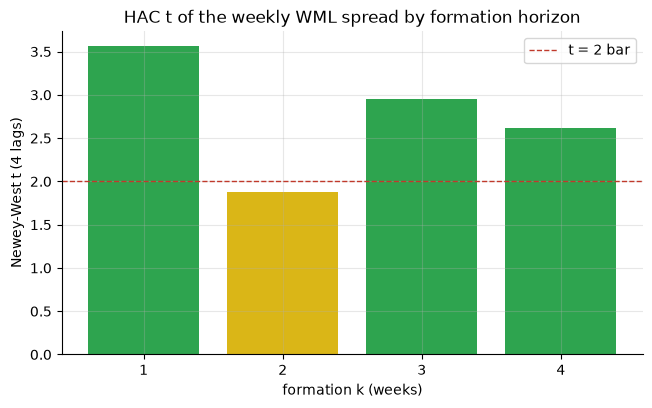

In [2]:
if HAVE_REAL:
    print(f"{'k':>2} {'weeks':>6} {'WML bps/wk':>11} {'ann%':>8} {'HAC t':>6} "
          f"{'SR':>5} {'hit%':>5}  {'WIN-MKT (t)':>14}")
    ts = {}
    for k in (1, 2, 3, 4):
        res = st.run_xs_momentum(PANEL, k=k)
        s = st.summarize(res['wml']); ex = st.summarize(res['win'] - res['mkt'])
        ts[k] = s['hac_t']
        print(f"{k:>2} {s['n']:>6} {s['mean_bps']:>+11.1f} {s['ann_pct']:>+8.1f} "
              f"{s['hac_t']:>+6.2f} {s['sharpe']:>5.2f} {s['hit_pct']:>5.1f}  "
              f"{ex['mean_bps']:>+8.1f} ({ex['hac_t']:+.2f})")
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ks = list(ts); vals = [ts[k] for k in ks]
    ax.bar([str(k) for k in ks], vals,
           color=[GREEN if v >= 2 else AMBER for v in vals])
    ax.axhline(2, color=RED, ls='--', lw=1, label='t = 2 bar')
    ax.set_title('HAC t of the weekly WML spread by formation horizon')
    ax.set_xlabel('formation k (weeks)'); ax.set_ylabel('Newey-West t (4 lags)')
    ax.legend(); plt.show()
else:
    print('cache missing — frozen:', R['headline'])

> 💡 **In plain words.** Buying last week's top coins and shorting the bottom ones paid about **+1.6% a week before costs** for nine years — and the odds that a random pattern produces a *t* of 3.56 are far below the desk's tolerance. The 2-week sort dips under the bar (*t* = 1.88); 3- and 4-week sorts clear it — the effect is a horizon *band*, not a single lucky knob.

Context: the equal-weight market itself earns +148 bps/wk at only *t* = 1.9 — crypto **beta** alone can't certify itself; the momentum **spread** can.

## 2 · Sub-periods & the bear-regime split (the third axis)

Two cuts, both pre-registered by the claim itself: calendar sub-periods, and a **tradable** regime flag — BTC above/below its 30-week SMA at the *formation* close, applied to the *next* week (same lag as the strategy, no look-ahead).

2017-2019: n=111   +194.6 bps/wk  HAC t=+1.62  hit=55.9%
2020-2021: n=104   +371.6 bps/wk  HAC t=+3.80  hit=63.5%
2022     : n= 52    +10.5 bps/wk  HAC t=+0.13  hit=48.1%
2023-2026: n=182    +70.8 bps/wk  HAC t=+1.30  hit=51.6%

bull: n=243  WML  +255.8 bps/wk  HAC t=+3.51  SR=1.47
bear: n=206  WML   +56.0 bps/wk  HAC t=+1.13  SR=0.55
Welch t (bull - bear) = +2.09


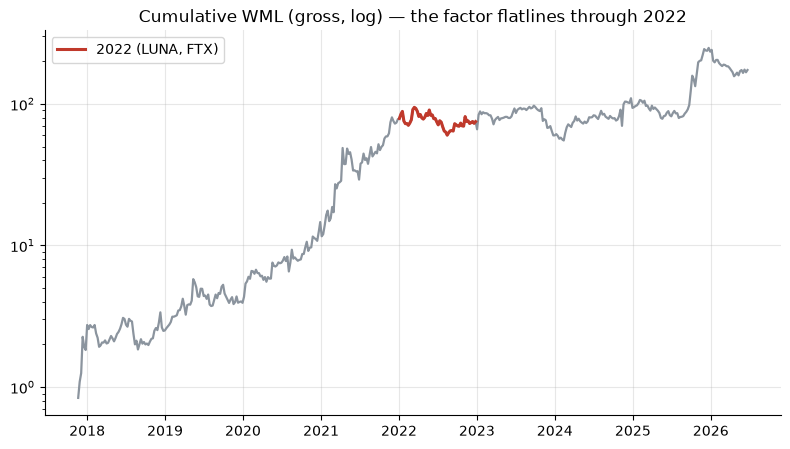

In [3]:
if HAVE_REAL:
    for a, b, lab in [('2017-01-01', '2019-12-31', '2017-2019'),
                      ('2020-01-01', '2021-12-31', '2020-2021'),
                      ('2022-01-01', '2022-12-31', '2022     '),
                      ('2023-01-01', '2026-06-28', '2023-2026')]:
        s = st.sub_period(RES, a, b)
        print(f"{lab}: n={s['n']:>3}  {s['mean_bps']:>+7.1f} bps/wk  "
              f"HAC t={s['hac_t']:>+5.2f}  hit={s['hit_pct']:.1f}%")
    rs = st.regime_split(RES, st.btc_regime(PANEL))
    print()
    for lab in ('bull', 'bear'):
        s = rs[lab]
        print(f"{lab}: n={s['n']:>3}  WML {s['mean_bps']:>+7.1f} bps/wk  "
              f"HAC t={s['hac_t']:>+5.2f}  SR={s['sharpe']:.2f}")
    print(f"Welch t (bull - bear) = {rs['welch_t_diff']:+.2f}")
    cum = (1 + RES['wml']).cumprod()
    fig, ax = plt.subplots()
    ax.plot(cum.index, cum, color=GREY, lw=1.6)
    m22 = (cum.index >= '2022-01-01') & (cum.index <= '2022-12-31')
    ax.plot(cum.index[m22], cum[m22], color=RED, lw=2.2, label='2022 (LUNA, FTX)')
    ax.set_yscale('log'); ax.legend()
    ax.set_title('Cumulative WML (gross, log) — the factor flatlines through 2022')
    plt.show()
else:
    print('frozen:', R['subs'], R['bull'], R['bear'], R['welch_diff'])

> 💡 **In plain words.** All the certification lives in the bull years: 2020–2021 alone runs at *t* = 3.8, while **2022 — the year of LUNA and FTX — paid +10.5 bps/week at *t* = 0.13**: nothing. In bear-regime weeks overall the spread is +56 bps/wk at *t* = 1.13 (can't certify), in bull weeks +256 at *t* = 3.51, and the difference itself is significant (Welch *t* = 2.09). **"Does it survive the 2022 bear?" — Busted.** Notably it doesn't *lose* in bears — momentum crashes of the equity kind don't show here — it just stops paying.

## 3 · Costs — turnover × fee grid, shorts pay borrow

Weekly quintiles churn brutally; we *measure* traded NAV (buys + sells, each paying the one-way cost) instead of assuming it, and charge the short leg 10%/yr borrow (perp funding, historically positive, would usually *pay* a short — the charge is conservative).

measured turnover: winners 1.48x NAV/wk, losers 1.60x NAV/wk
c=  10 bps: WML net  +114.1 bps/wk (ann  +80.7%)  t=+2.47 | long-only exc  +98.4 bps/wk  t=+2.86
c=  25 bps: WML net   +67.8 bps/wk (ann  +42.3%)  t=+1.46 | long-only exc  +76.1 bps/wk  t=+2.21
c=  50 bps: WML net    -9.3 bps/wk (ann   -4.7%)  t=-0.20 | long-only exc  +39.0 bps/wk  t=+1.13


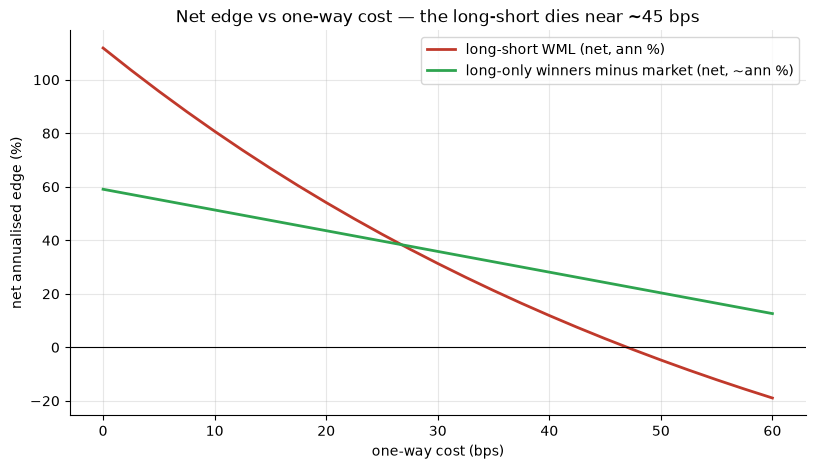

In [4]:
if HAVE_REAL:
    print(f"measured turnover: winners {RES['to_win'].mean():.2f}x NAV/wk, "
          f"losers {RES['to_lose'].mean():.2f}x NAV/wk")
    for c in (10.0, 25.0, 50.0):
        nw = st.summarize(st.net_wml(RES, c))
        ex = st.summarize(st.net_long_only(RES, c) - RES['mkt'])
        print(f"c={c:>4.0f} bps: WML net {nw['mean_bps']:>+7.1f} bps/wk "
              f"(ann {nw['ann_pct']:>+6.1f}%)  t={nw['hac_t']:>+5.2f} | "
              f"long-only exc {ex['mean_bps']:>+6.1f} bps/wk  t={ex['hac_t']:>+5.2f}")
    cs = np.linspace(0, 60, 25)
    ann_ls = [st.summarize(st.net_wml(RES, c))['ann_pct'] for c in cs]
    ann_lo = [st.summarize(st.net_long_only(RES, c) - RES['mkt'])['mean_bps'] * 52.18 / 100
              for c in cs]
    fig, ax = plt.subplots()
    ax.plot(cs, ann_ls, color=RED, lw=2, label='long-short WML (net, ann %)')
    ax.plot(cs, ann_lo, color=GREEN, lw=2, label='long-only winners minus market (net, ~ann %)')
    ax.axhline(0, color='k', lw=.8)
    ax.set_title('Net edge vs one-way cost — the long-short dies near ~45 bps')
    ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net annualised edge (%)')
    ax.legend(); plt.show()
else:
    print('frozen:', R['costs'])

> 💡 **In plain words.** At big-pair taker fees (10 bps) the long-short still certifies (*t* = 2.47); at liquid-alt all-in costs (25 bps) it's positive but unprovable (*t* = 1.46); at thin-alt costs it's dead. The **long-only winners tilt** — no shorting, no borrow, half the churn — beats the market at *t* = 2.21 even at 25 bps: the deployable residue of the factor. Add that shorting the losers leg at size is partly fictional (borrow vanishes exactly when a coin is collapsing) and Tradability reads **Fragile**, not Investable.

## 4 · Placebo — 20-seed random ranks

Same eligibility, same quintile sizes, same lag — but ranks drawn from noise. Averaged over 20 seeds (single-seed baselines are banned at this desk).

In [5]:
if HAVE_REAL:
    pl = st.placebo_random_ranks(PANEL, k=1, n_seeds=20)
    print(f"shuffled WML mean = {pl['mean_bps']:+.1f} +/- {pl['std_bps']:.1f} bps/wk "
          f"({pl['n_seeds']} seeds) | mean HAC t = {pl['mean_hac_t']:+.2f}")
    print(f"observed WML mean = {R['headline'][0][2]:+.1f} bps/wk (HAC t = "
          f"{R['headline'][0][4]:+.2f}) — far outside the shuffled cloud")
else:
    print('frozen:', R['placebo'])

shuffled WML mean = +7.2 +/- 36.4 bps/wk (20 seeds) | mean HAC t = +0.20
observed WML mean = +164.1 bps/wk (HAC t = +3.56) — far outside the shuffled cloud


## 5 · Synthetic control — machinery proof *(never market evidence)*

A deterministic crypto-vol panel with a plantable idiosyncratic AR(1). At ρ = 0 the quintile detector must stay quiet; at ρ = 0.10 it must light up.

In [6]:
for rho in (0.0, 0.10):
    ps = data.synthetic_panel(rho=rho, seed=632)
    r = st.run_xs_momentum(ps, k=1)
    s = st.summarize(r['wml'])
    lab = 'null rho=0.00' if rho == 0 else 'planted rho=0.10'
    print(f"{lab}: WML {s['mean_bps']:>+7.1f} bps/wk  HAC t={s['hac_t']:>+6.2f}")

null rho=0.00: WML   -39.2 bps/wk  HAC t= -1.09
planted rho=0.10: WML  +396.7 bps/wk  HAC t=+11.14


> 💡 **In plain words.** The engine can't be fooled into finding momentum where none was planted, and can't miss it where it was. So the real-tape *t* = 3.56 is the market talking, not the code.

## Verdict

- **Signal — REAL.** +164 bps/wk WML, HAC *t* = 3.56, Sharpe 1.12, robust at k = 3, 4; placebo ~0. Survivorship named (softened by 11 delisted pairs incl. LUNA's −100% week, not removed).
- **Tradability — FRAGILE.** ~1.5× NAV/leg/week churn; net *t* = 2.47 at 10 bps but 1.46 at 25 bps and dead at 50; bull-loaded and decayed post-2022. Long-only tilt survives 25 bps (*t* = 2.21).
- **Survives the 2022 bear? — BUSTED.** +10.5 bps/wk, *t* = 0.13 through LUNA/FTX; bear-regime *t* = 1.13; bull−bear Welch *t* = 2.09.

*Single source of truth: [docs/results.md](../docs/results.md) · sources: [docs/references.md](../docs/references.md) · siblings: [251-crypto-reversal](../../251-crypto-reversal/README.md), [222-altseason-rotation](../../222-altseason-rotation/README.md), [210-crypto-trend](../../210-crypto-trend/README.md) · not investment advice.*